# Niño Index Timeseries — CESM2-LE vs COBE-SST2 Observations

Computes any standard Niño index from CESM2-LE monthly TS output (HIST and optionally SSP370 continuation),
removes the mean annual cycle, and compares to COBE-SST2 observed SST over a chosen period.

In [44]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy import signal

## Configuration

Set the case name stub, Niño region, and comparison period here.

In [45]:
# --- Model case ---
case_stub_hist = 'b.e21.BHISTcmip6.f09_g17.LE2-1001.001'
case_stub_ssp  = 'b.e21.BSSP370cmip6.f09_g17.LE2-1001.001'  # SSP370 continuation (2015+)

dir_ts = '/glade/campaign/cesm/collections/CESM2-LE/timeseries/atm/proc/tseries/month_1/TS/'

# Include SSP370 files to extend model to 2025?
include_ssp = True

# --- Niño region ---
# Options: 'nino12', 'nino3', 'nino34', 'nino4'
nino_reg = 'nino34'

# --- Observed SST ---
obs_file = '/glade/campaign/cesm/cesmdata/cseg/inputdata/atm/cam/sst/sst_COBE-SST2_bc_0.9x1.25_1850_2025_c250710.nc'

# --- Comparison period for timeseries plots (obs vs model) ---
comp_yr0 = 1970
comp_yr1 = 2025

# --- Year range for the 2-D anomaly maps ---
map_yr0 = 1997
map_yr1 = 1998   # e.g. the 1997-98 El Niño; change to any period

# --- Output figure directory (set to '.' for current directory) ---
dir_fig = '.'

## Helper functions

In [46]:
# Standard Niño region lat/lon bounds (all longitudes in 0–360°E)
NINO_REGIONS = {
    'nino12': dict(lon_w=270., lon_e=280., lat_s=-10., lat_n=0.),
    'nino3':  dict(lon_w=210., lon_e=270., lat_s= -5., lat_n=5.),
    'nino34': dict(lon_w=190., lon_e=240., lat_s= -5., lat_n=5.),
    'nino4':  dict(lon_w=160., lon_e=210., lat_s= -5., lat_n=5.),
}

NINO_LABELS = {
    'nino12': 'Niño 1+2  (0–10°S, 80–90°W)',
    'nino3':  'Niño 3    (5°S–5°N, 90–150°W)',
    'nino34': 'Niño 3.4  (5°S–5°N, 120–170°W)',
    'nino4':  'Niño 4    (5°S–5°N, 160°E–150°W)',
}


def compute_nino_index(da, nino_name, detrend=True):
    """Area-weighted mean in the Niño box, remove monthly climatology, optionally detrend."""
    r = NINO_REGIONS[nino_name]
    region = da.sel(lat=slice(r['lat_s'], r['lat_n']),
                    lon=slice(r['lon_w'], r['lon_e']))
    weights = np.cos(np.deg2rad(region.lat))
    ts = region.weighted(weights).mean(dim=['lat', 'lon'])
    clim = ts.groupby('time.month').mean('time')
    anom = ts.groupby('time.month') - clim
    if detrend:
        anom.values = signal.detrend(anom.values)
    return anom


def mean_sst_anom_2d(da, yr0, yr1):
    """
    Time-mean 2-D SST anomaly map over [yr0, yr1].
    Climatology is computed from the full da time dimension.
    """
    clim = da.groupby('time.month').mean('time')
    anom = da.groupby('time.month') - clim
    mask = (anom.time.dt.year >= yr0) & (anom.time.dt.year <= yr1)
    return anom.sel(time=mask).mean('time')


def year_float(da):
    """Fractional year for x-axis (works with cftime NoLeap calendars)."""
    return da.time.dt.year + (da.time.dt.dayofyear - 1) / 365.


def fill_ts(ax, xdata, ydata, color_pos='red', color_neg='blue', lw=0.5, **kwargs):
    ax.plot(xdata, ydata, color='black', linewidth=lw, **kwargs)
    ax.fill_between(xdata, ydata, 0,
                    where=(np.asarray(ydata) >= 0), facecolor=color_pos,
                    interpolate=True, alpha=0.7)
    ax.fill_between(xdata, ydata, 0,
                    where=(np.asarray(ydata) <= 0), facecolor=color_neg,
                    interpolate=True, alpha=0.7)

## Load model TS data

In [47]:
hist_files = sorted(glob.glob(dir_ts + case_stub_hist + '.cam.h0.TS.*.nc'))
print(f'HIST files found: {len(hist_files)}')
print(f'  First: {hist_files[0].split("/")[-1]}')
print(f'  Last:  {hist_files[-1].split("/")[-1]}')

model_files = hist_files

if include_ssp:
    ssp_files = sorted(glob.glob(dir_ts + case_stub_ssp + '.cam.h0.TS.*.nc'))
    # Only keep SSP files whose start year is <= comp_yr1
    ssp_files = [f for f in ssp_files
                 if int(f.split('.')[-2].split('-')[0][:4]) <= comp_yr1]
    print(f'\nSSP370 files included: {len(ssp_files)}')
    if ssp_files:
        print(f'  First: {ssp_files[0].split("/")[-1]}')
        print(f'  Last:  {ssp_files[-1].split("/")[-1]}')
    model_files = hist_files + ssp_files

print(f'\nTotal model files to read: {len(model_files)}')

HIST files found: 17
  First: b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.TS.185001-185912.nc
  Last:  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h0.TS.201001-201412.nc

SSP370 files included: 2
  First: b.e21.BSSP370cmip6.f09_g17.LE2-1001.001.cam.h0.TS.201501-202412.nc
  Last:  b.e21.BSSP370cmip6.f09_g17.LE2-1001.001.cam.h0.TS.202501-203412.nc

Total model files to read: 19


In [48]:
# Open lazily — we only need the tropical Pacific strip so this is fast
ds_model = xr.open_mfdataset(
    model_files,
    combine='by_coords',
    data_vars='minimal',
    coords='minimal',
    compat='override',
    parallel=True,
)
da_ts = ds_model['TS']
print(da_ts)
print(f'Model time range: {int(da_ts.time.dt.year[0])} – {int(da_ts.time.dt.year[-1])}')

<xarray.DataArray 'TS' (time: 2220, lat: 192, lon: 288)> Size: 491MB
dask.array<concatenate, shape=(2220, 192, 288), dtype=float32, chunksize=(1, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 18kB 1850-02-01 00:00:00 ... 2035-01-01 00:00:00
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    units:         K
    long_name:     Surface temperature (radiative)
    cell_methods:  time: mean
Model time range: 1850 – 2035


## Compute model Niño index

In [49]:
print(f'Computing {NINO_LABELS[nino_reg]} index from model TS ...')
nino_model = compute_nino_index(da_ts, nino_reg)
nino_model = nino_model.compute()   # trigger load
xf_model = year_float(nino_model).values
print('Done.')

Computing Niño 3.4  (5°S–5°N, 120–170°W) index from model TS ...
Done.


## Load COBE-SST2 observed SST and compute Niño index

In [50]:
# COBE-SST2: SST_cpl in °C, 0.9×1.25° grid, 365-day calendar
# Anomalies are comparable to model K anomalies (offset cancels)
ds_obs = xr.open_dataset(obs_file, use_cftime=True)
da_obs = ds_obs['SST_cpl']

# Subset to the comparison period before computing the index
da_obs_comp = da_obs.sel(
    time=(da_obs.time.dt.year >= comp_yr0) & (da_obs.time.dt.year <= comp_yr1)
)

print(f'Obs time range (comparison window): '
      f'{int(da_obs_comp.time.dt.year[0])} – {int(da_obs_comp.time.dt.year[-1])}')
print(f'Computing {NINO_LABELS[nino_reg]} index from COBE-SST2 ...')
nino_obs = compute_nino_index(da_obs_comp, nino_reg)
xf_obs = year_float(nino_obs).values
print('Done.')

/glade/derecho/scratch/rneale/tmp/ipykernel_12931/37360929.py:3: DeprecationWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds_obs = xr.open_dataset(obs_file, use_cftime=True)


Obs time range (comparison window): 1970 – 2025
Computing Niño 3.4  (5°S–5°N, 120–170°W) index from COBE-SST2 ...
Done.


## Plot 1 — Full model Niño timeseries

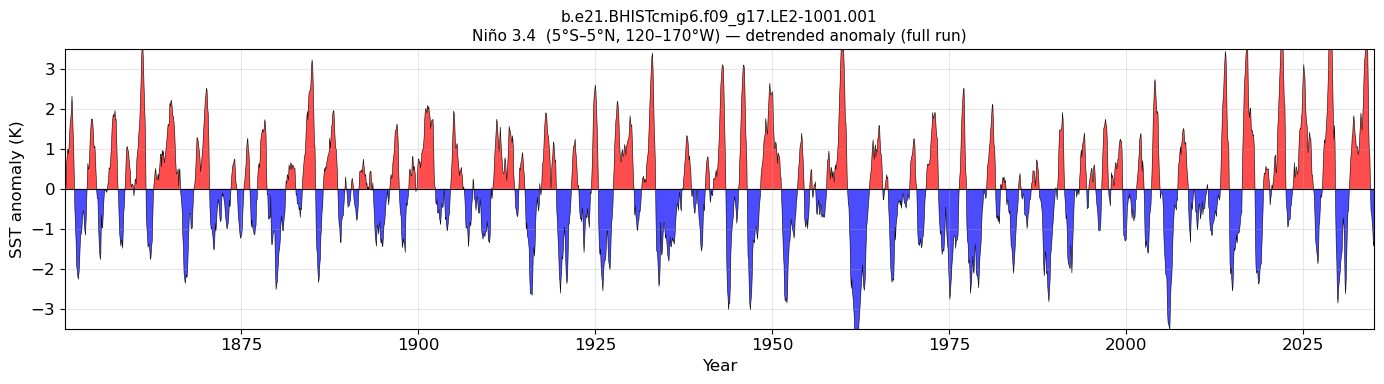

In [51]:
fig, ax = plt.subplots(figsize=(14, 4))
plt.rcParams.update({'font.size': 12})

ymod = nino_model.values
fill_ts(ax, xf_model, ymod, lw=0.4)

ax.set_xlim(xf_model[0], xf_model[-1])
ax.axhline(0, color='black', lw=0.8)
ax.set_ylim(-3.5, 3.5)
ax.set_xlabel('Year')
ax.set_ylabel('SST anomaly (K)')
ax.set_title(
    f'{case_stub_hist}\n'
    f'{NINO_LABELS[nino_reg]} — detrended anomaly (full run)',
    fontsize=11
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f'{dir_fig}/{case_stub_hist}_{nino_reg}_full_ts.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot 2 — Model vs COBE-SST2 comparison

/glade/derecho/scratch/rneale/tmp/ipykernel_12931/3786957293.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


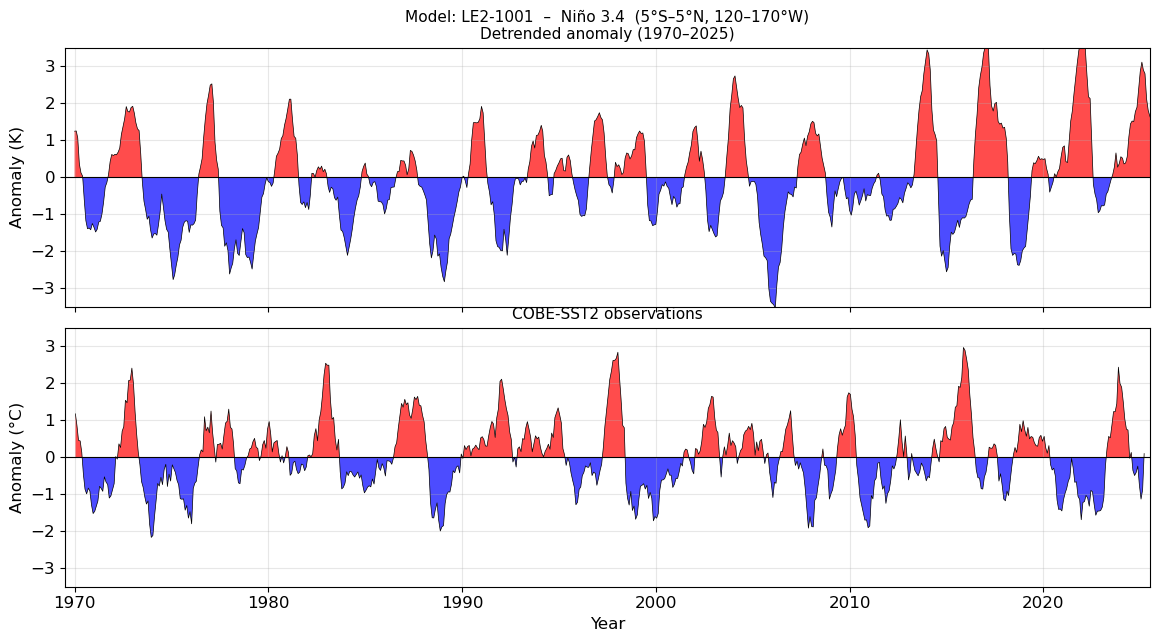

In [52]:
# Subset model to the comparison period for this plot
mask_comp = (nino_model.time.dt.year >= comp_yr0) & (nino_model.time.dt.year <= comp_yr1)
nino_model_comp = nino_model.sel(time=mask_comp)
xf_model_comp = year_float(nino_model_comp).values

fig = plt.figure(figsize=(14, 7))
plt.rcParams.update({'font.size': 12})
gs = gridspec.GridSpec(2, 1, hspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# --- Model ---
fill_ts(ax1, xf_model_comp, nino_model_comp.values, lw=0.5)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_ylim(-3.5, 3.5)
ax1.set_ylabel('Anomaly (K)')
ax1.set_title(
    f'Model: {case_stub_hist.split(".")[4]}  –  {NINO_LABELS[nino_reg]}\n'
    f'Detrended anomaly ({comp_yr0}–{comp_yr1})',
    fontsize=11
)
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelbottom=False)

# --- Observations ---
fill_ts(ax2, xf_obs, nino_obs.values, lw=0.5)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylim(-3.5, 3.5)
ax2.set_ylabel('Anomaly (°C)')
ax2.set_xlabel('Year')
ax2.set_title('COBE-SST2 observations', fontsize=11)
ax2.grid(True, alpha=0.3)

xlims = (comp_yr0 - 0.5, comp_yr1 + 0.5)
ax1.set_xlim(*xlims)

plt.tight_layout()
fig.savefig(
    f'{dir_fig}/{case_stub_hist}_{nino_reg}_vs_COBE_{comp_yr0}-{comp_yr1}.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

## Plot 3 — Overlay comparison (model + obs on same panel)

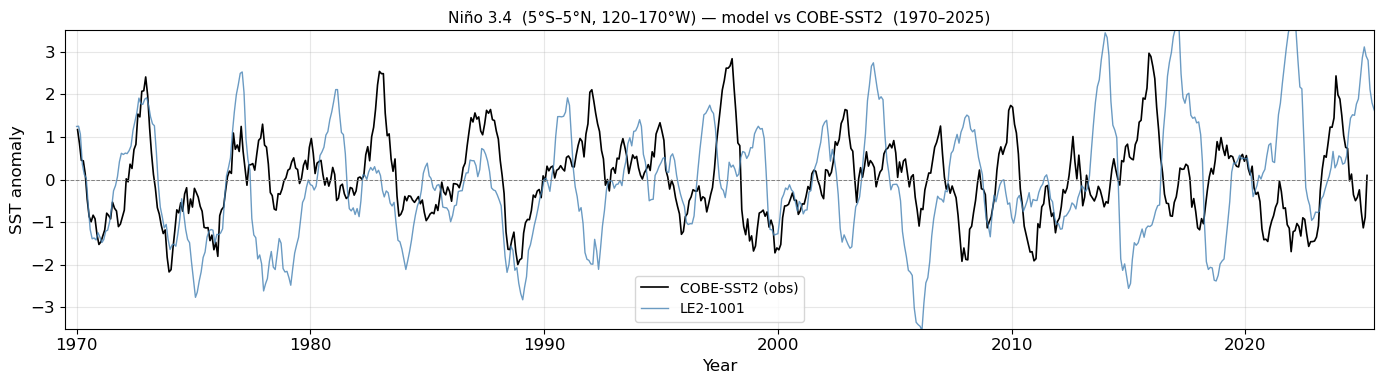

In [53]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(xf_obs, nino_obs.values, color='black', lw=1.2, label='COBE-SST2 (obs)')
ax.plot(xf_model_comp, nino_model_comp.values, color='steelblue',
        lw=1.0, alpha=0.8, label=case_stub_hist.split('.')[4])

ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_xlim(*xlims)
ax.set_ylim(-3.5, 3.5)
ax.set_xlabel('Year')
ax.set_ylabel('SST anomaly')
ax.set_title(f'{NINO_LABELS[nino_reg]} — model vs COBE-SST2  ({comp_yr0}–{comp_yr1})', fontsize=11)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(
    f'{dir_fig}/{case_stub_hist}_{nino_reg}_overlay_{comp_yr0}-{comp_yr1}.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

## Summary statistics

In [54]:
corr = np.corrcoef(nino_model_comp.values, nino_obs.values)[0, 1] if len(nino_model_comp) == len(nino_obs) else np.nan

print(f'Region : {NINO_LABELS[nino_reg]}')
print(f'Period : {comp_yr0}–{comp_yr1}')
print()
print(f'Model std dev : {float(nino_model_comp.std()):.3f} K')
print(f'Obs   std dev : {float(nino_obs.std()):.3f} °C')
if not np.isnan(corr):
    print(f'Correlation   : {corr:.3f}')
else:
    print('Correlation: time arrays differ in length — check overlap')

Region : Niño 3.4  (5°S–5°N, 120–170°W)
Period : 1970–2025

Model std dev : 1.341 K
Obs   std dev : 0.939 °C
Correlation: time arrays differ in length — check overlap


## Spatial maps — mean SST anomaly over a chosen year range

Average the full 2-D SST anomaly field (model TS and COBE-SST2) over `map_yr0`–`map_yr1`
and plot them side-by-side on a Pacific-centred global map.

In [55]:
print(f'Computing model 2-D anomaly map ({map_yr0}–{map_yr1}) ...')
map_model = mean_sst_anom_2d(da_ts, map_yr0, map_yr1).compute()
print('Done.')

# Use the full obs record for climatology so the base period is not restricted to comp window
print(f'Computing COBE 2-D anomaly map ({map_yr0}–{map_yr1}) ...')
map_obs = mean_sst_anom_2d(da_obs, map_yr0, map_yr1)
print('Done.')

Computing model 2-D anomaly map (1997–1998) ...
Done.
Computing COBE 2-D anomaly map (1997–1998) ...
Done.


/glade/derecho/scratch/rneale/tmp/ipykernel_12931/2202501668.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 1])


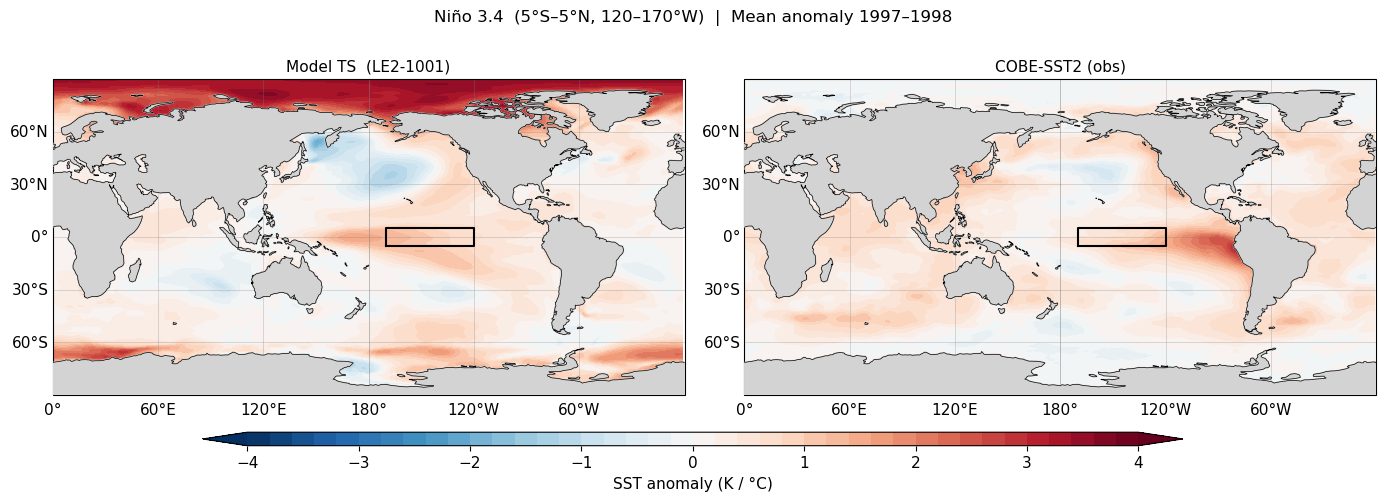

In [56]:
# Shared symmetric colour scale — auto-scaled then rounded to nearest 0.5 K
vmax = max(float(abs(map_model).max()), float(abs(map_obs).max()))
vmax = np.ceil(vmax * 2) / 2
clev = np.linspace(-vmax, vmax, 41)
cmap = plt.get_cmap('RdBu_r')

proj = ccrs.PlateCarree(central_longitude=180.)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         subplot_kw=dict(projection=proj))
plt.rcParams.update({'font.size': 11})

panels = [
    (map_model, f'Model TS  ({case_stub_hist.split(".")[4]})'),
    (map_obs,   'COBE-SST2 (obs)'),
]

for ax, (data, title) in zip(axes, panels):
    cf = ax.contourf(
        data.lon, data.lat, data,
        levels=clev, cmap=cmap, extend='both',
        transform=ccrs.PlateCarree(),
    )
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=4)
    ax.set_global()
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(title, fontsize=11)

    # Draw the selected Niño box
    r = NINO_REGIONS[nino_reg]
    lons = [r['lon_w'], r['lon_e'], r['lon_e'], r['lon_w'], r['lon_w']]
    lats = [r['lat_s'], r['lat_s'], r['lat_n'], r['lat_n'], r['lat_s']]
    ax.plot(lons, lats, 'k-', lw=1.5, transform=ccrs.PlateCarree(), zorder=5)

cbar_ax = fig.add_axes([0.15, 0.04, 0.70, 0.03])
fig.colorbar(cf, cax=cbar_ax, orientation='horizontal',
             label='SST anomaly (K / °C)',
             ticks=np.arange(-vmax, vmax + 0.5, 1))

fig.suptitle(
    f'{NINO_LABELS[nino_reg]}  |  Mean anomaly {map_yr0}–{map_yr1}',
    fontsize=12, y=1.01
)
plt.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(
    f'{dir_fig}/{case_stub_hist}_{nino_reg}_map_{map_yr0}-{map_yr1}.png',
    dpi=150, bbox_inches='tight'
)
plt.show()